# 04 — Profitability & Customer Segmentation
**Financial Operations Analytics**

This notebook turns the customer base into actionable value tiers and quantifies
profit risk:
1. **K-Means segmentation** (k chosen in the 5–7 range via elbow + silhouette)
2. **RFM scoring** of the base
3. **Cohort retention heatmap** by signup cohort
4. **Monte Carlo simulation** (1,000 iterations) of annual profit
5. **OLS regression** on the drivers of monthly profit

Outputs `data/processed/customer_segments.csv`, consumed by the dashboard (NB 05).


In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "dashboard"} else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.viz import set_style, save_fig, DANGER
from src.features import add_rfm, add_clv
set_style()

PROC = ROOT / "data" / "processed" / "telco_clean.csv"
SCORED = ROOT / "data" / "processed" / "churn_scored.csv"
SEG_OUT = ROOT / "data" / "processed" / "customer_segments.csv"
RANDOM_STATE = 42

df = pd.read_csv(PROC)
df = add_clv(df)          # model-based CLV
df = add_rfm(df)          # RFM scores + segment
print(df[["CLV", "RFM_Score", "RFM_Segment"]].head())

      CLV  RFM_Score     RFM_Segment
0  122.07          9  Need Attention
1  308.26         10           Loyal
2  278.56         14       Champions
3  259.65         12           Loyal
4  362.61          7  Need Attention


## 1. K-Means value segmentation
Customers are clustered on standardized value signals — lifetime spend, tenure,
monthly charges, monthly profit and CLV. We sweep k = 5..7 and pick the k with the
best silhouette score.

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

seg_features = ["Total Charges", "Tenure Months", "Monthly Charges",
                "MonthlyProfit", "CLV"]
Xs = StandardScaler().fit_transform(df[seg_features])

sweep = {}
for k in range(5, 8):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(Xs)
    sweep[k] = silhouette_score(Xs, km.labels_)
best_k = max(sweep, key=sweep.get)
print("Silhouette by k:", {k: round(v, 3) for k, v in sweep.items()})
print("Chosen k:", best_k)

Silhouette by k: {5: 0.392, 6: 0.339, 7: 0.369}
Chosen k: 5


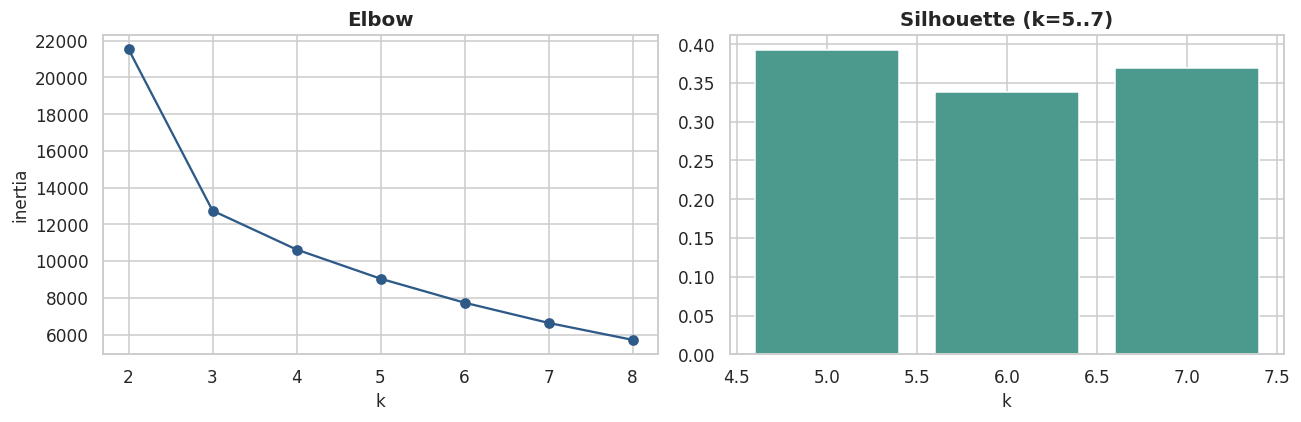

In [3]:
# Elbow + silhouette diagnostic
inertias = [KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(Xs).inertia_
            for k in range(2, 9)]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(range(2, 9), inertias, "o-", color="#2E5A88"); ax[0].set_title("Elbow")
ax[0].set_xlabel("k"); ax[0].set_ylabel("inertia")
ax[1].bar(list(sweep.keys()), list(sweep.values()), color="#4C9A8E")
ax[1].set_title("Silhouette (k=5..7)"); ax[1].set_xlabel("k")
plt.tight_layout(); save_fig(fig, "04_kmeans_selection"); plt.show()

In [4]:
km = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10).fit(Xs)
df["Cluster"] = km.labels_
# Name tiers by descending mean monthly profit.
tier_names = ["Platinum", "Gold", "Silver", "Bronze", "Standard", "Basic", "Entry"]
order = (df.groupby("Cluster")["MonthlyProfit"].mean()
         .sort_values(ascending=False).index.tolist())
cluster_to_tier = {c: tier_names[i] for i, c in enumerate(order)}
df["Segment"] = df["Cluster"].map(cluster_to_tier)
seg_order = [tier_names[i] for i in range(best_k)]

summary = (df.groupby("Segment")
           .agg(Customers=("CustomerID", "count"),
                AvgMonthlyProfit=("MonthlyProfit", "mean"),
                AvgCLV=("CLV", "mean"),
                AvgTenure=("Tenure Months", "mean"),
                ChurnRate=("Churn Value", "mean"),
                TotalMonthlyProfit=("MonthlyProfit", "sum"))
           .reindex(seg_order).round(2))
summary

,Customers,AvgMonthlyProfit,AvgCLV,AvgTenure,ChurnRate,TotalMonthlyProfit
Segment,,,,,,
Platinum,677,23.65,620.39,52.73,0.10,16012.38
Gold,2197,19.46,236.68,11.65,0.52,42756.15
Silver,2326,18.58,234.45,58.87,0.25,43223.92
Bronze,868,-2.23,16.35,11.57,0.33,-1939.34
Standard,975,-3.03,14.82,58.18,0.10,-2958.37


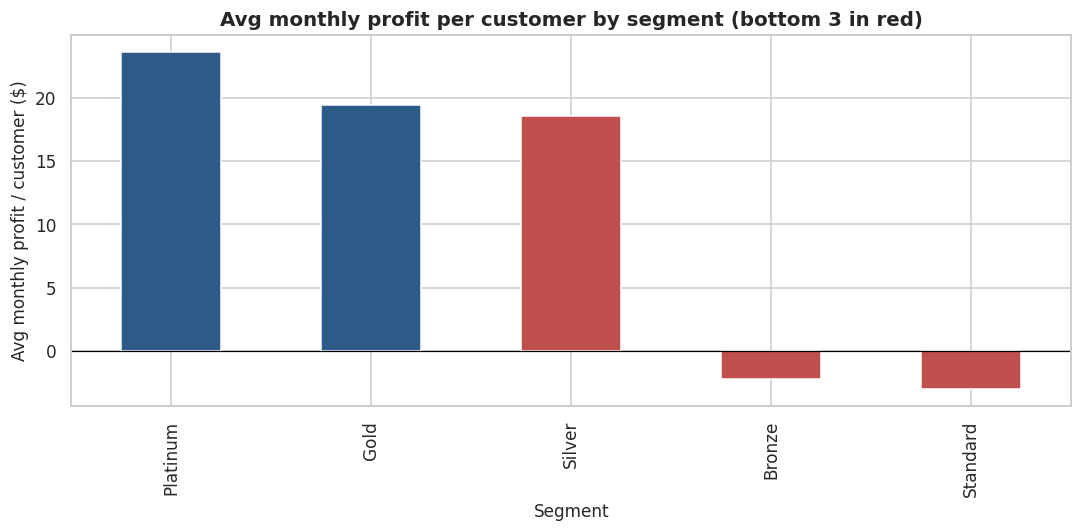

Bottom 3 segments: ['Silver', 'Bronze', 'Standard']


In [5]:
# Avg profit-per-customer by segment, bottom 3 tiers in red (matches dashboard).
# Per-customer profit keeps the tier names and the red highlight consistent
# (premium tiers stay at the top regardless of segment size).
seg_profit = summary["AvgMonthlyProfit"].sort_values(ascending=False)
bottom3 = seg_profit.tail(3).index
colors = [DANGER if s in bottom3 else "#2E5A88" for s in seg_profit.index]
fig, ax = plt.subplots(figsize=(10, 5))
seg_profit.plot.bar(ax=ax, color=colors)
ax.axhline(0, color="black", lw=.8)
ax.set_title("Avg monthly profit per customer by segment (bottom 3 in red)")
ax.set_ylabel("Avg monthly profit / customer ($)")
plt.tight_layout(); save_fig(fig, "04_profit_by_segment"); plt.show()
print("Bottom 3 segments:", list(bottom3))

## 2. RFM segment distribution

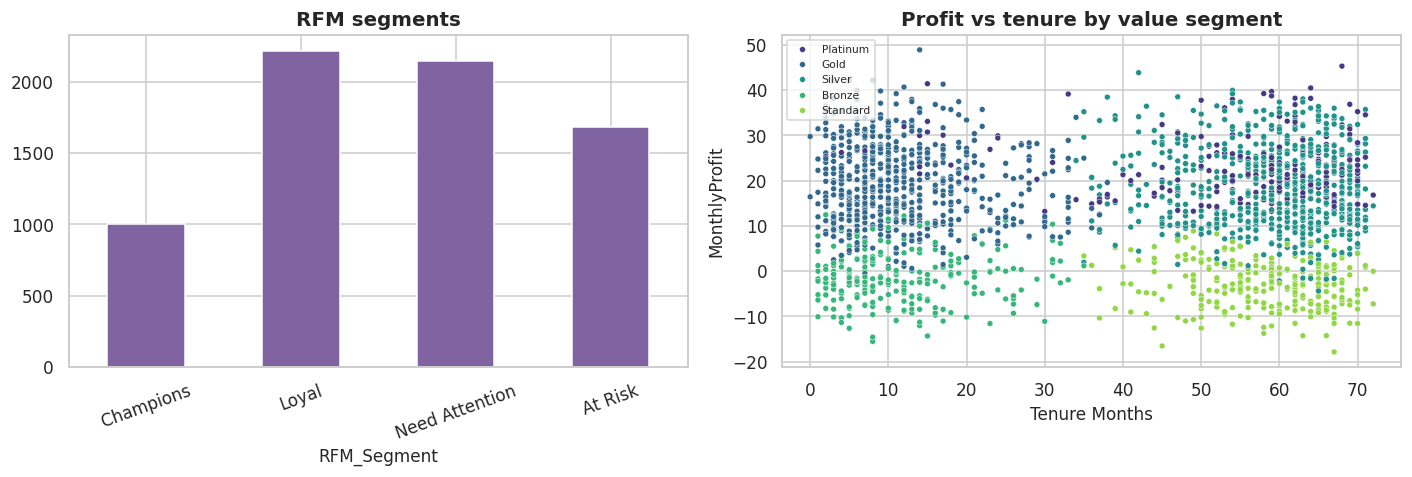

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
df["RFM_Segment"].value_counts().reindex(
    ["Champions", "Loyal", "Need Attention", "At Risk"]).plot.bar(
    ax=ax[0], color="#8064A2")
ax[0].set_title("RFM segments"); ax[0].tick_params(axis="x", rotation=20)
sns.scatterplot(data=df.sample(2000, random_state=1), x="Tenure Months",
                y="MonthlyProfit", hue="Segment", palette="viridis",
                hue_order=seg_order, s=15, ax=ax[1])
ax[1].set_title("Profit vs tenure by value segment")
ax[1].legend(fontsize=7, loc="upper left")
plt.tight_layout(); save_fig(fig, "04_rfm_segments"); plt.show()

## 3. Cohort retention heatmap
Customers are grouped by **signup quarter**; each cell shows the share of the cohort
still active *k* months after signup (a customer is active at month k while
`k < tenure`).

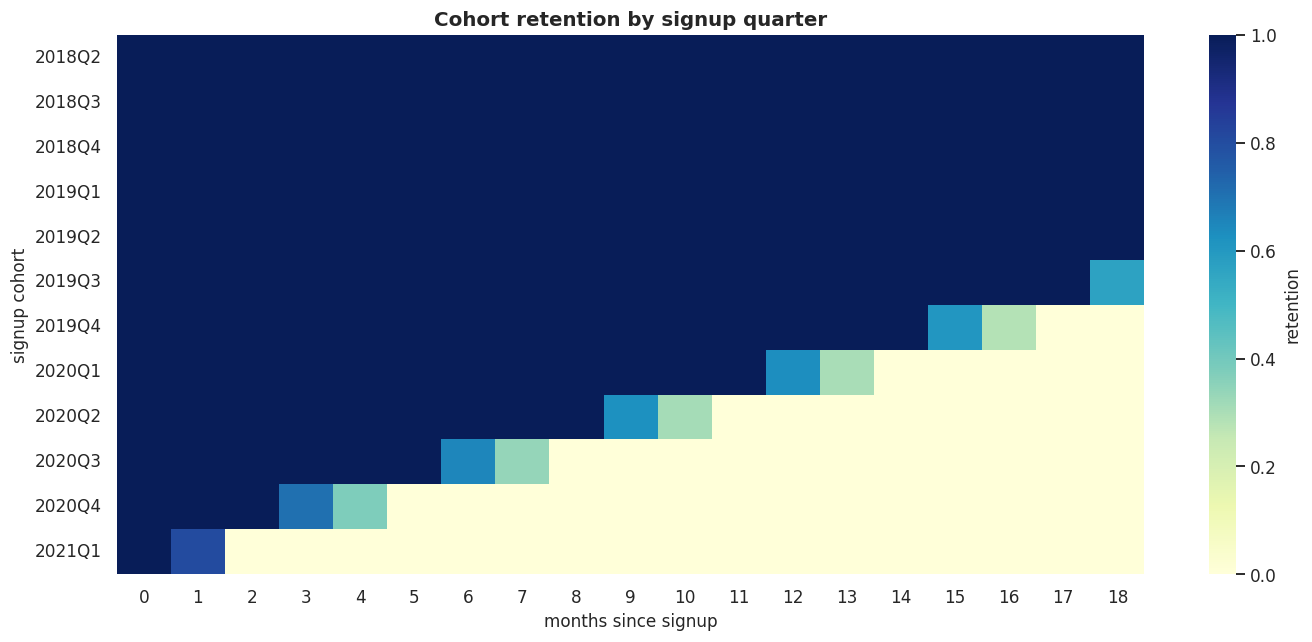

In [7]:
df["SignupMonth"] = pd.to_datetime(df["SignupMonth"])
df["Cohort"] = df["SignupMonth"].dt.to_period("Q").astype(str)
periods = range(0, 19)
cohorts = sorted(df["Cohort"].unique())[-12:]   # last 12 quarterly cohorts
mat = pd.DataFrame(index=cohorts, columns=list(periods), dtype=float)
for ch in cohorts:
    sub = df[df["Cohort"] == ch]
    base = len(sub)
    for k in periods:
        mat.loc[ch, k] = (sub["Tenure Months"] >= k).mean() if base else np.nan

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(mat.astype(float), annot=False, cmap="YlGnBu", vmin=0, vmax=1,
            cbar_kws={"label": "retention"}, ax=ax)
ax.set_title("Cohort retention by signup quarter"); ax.set_xlabel("months since signup")
ax.set_ylabel("signup cohort")
plt.tight_layout(); save_fig(fig, "04_cohort_retention"); plt.show()

## 4. Monte Carlo simulation — annual profit (1,000 iterations)
We simulate next-year profit under uncertainty in **monthly profit per customer**,
**active customer count**, and **churn rate**, drawing 1,000 scenarios.

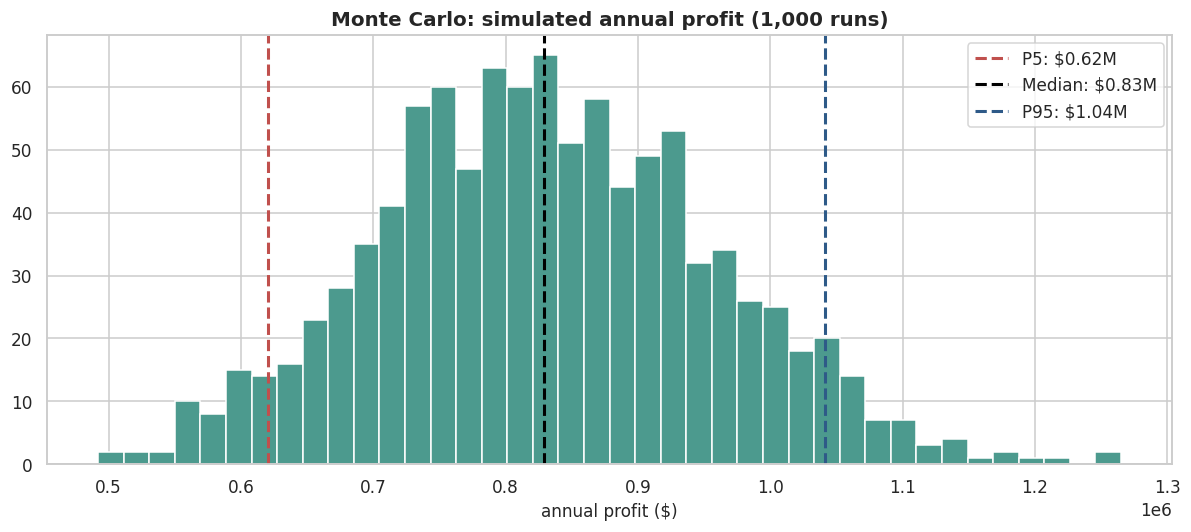

Median $0.83M | 90% interval [$0.62M, $1.04M]
P(annual profit < $0): 0.0%


In [8]:
rng = np.random.default_rng(RANDOM_STATE)
N_ITER = 1000
n_customers = len(df)
profit_mean, profit_sd = df["MonthlyProfit"].mean(), df["MonthlyProfit"].std()
base_churn = df["Churn Value"].mean()

annual = np.empty(N_ITER)
for i in range(N_ITER):
    pm = rng.normal(profit_mean, profit_sd * 0.15)              # avg profit/customer
    churn = np.clip(rng.normal(base_churn, 0.03), 0.05, 0.6)    # annual churn
    growth = rng.normal(0.03, 0.05)                             # net base growth
    eff_customers = n_customers * (1 - churn) * (1 + growth)
    annual[i] = pm * eff_customers * 12

p5, p50, p95 = np.percentile(annual, [5, 50, 95])
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(annual, bins=40, color="#4C9A8E", edgecolor="white")
for v, lbl, c in [(p5, "P5", DANGER), (p50, "Median", "black"), (p95, "P95", "#2E5A88")]:
    ax.axvline(v, color=c, ls="--", lw=2, label=f"{lbl}: ${v/1e6:.2f}M")
ax.set_title("Monte Carlo: simulated annual profit (1,000 runs)")
ax.set_xlabel("annual profit ($)"); ax.legend()
plt.tight_layout(); save_fig(fig, "04_monte_carlo"); plt.show()
print(f"Median ${p50/1e6:.2f}M | 90% interval [${p5/1e6:.2f}M, ${p95/1e6:.2f}M]")
print(f"P(annual profit < $0): {(annual < 0).mean():.1%}")

## 5. OLS — drivers of monthly profit
A linear model of `MonthlyProfit` on customer attributes (not its own cost inputs),
to read off which traits are associated with higher profitability.

In [9]:
import statsmodels.formula.api as smf
ols_df = df.copy()
ols_df["NumAddons"] = (ols_df[["Online Security", "Online Backup", "Device Protection",
                               "Tech Support", "Streaming TV", "Streaming Movies"]] == "Yes").sum(axis=1)
ols_df.columns = [c.replace(" ", "_") for c in ols_df.columns]
model = smf.ols(
    "MonthlyProfit ~ Tenure_Months + NumAddons + C(Internet_Service) + "
    "C(Contract) + C(Region) + Senior_Citizen + C(Paperless_Billing)",
    data=ols_df).fit()
print(model.summary().tables[1])
print(f"\nR-squared: {model.rsquared:.3f}")

                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             13.5825      0.293     46.340      0.000      13.008      14.157
C(Internet_Service)[T.Fiber optic]     7.8688      0.179     44.080      0.000       7.519       8.219
C(Internet_Service)[T.No]            -13.1101      0.270    -48.523      0.000     -13.640     -12.581
C(Contract)[T.One year]               -4.3354      0.203    -21.404      0.000      -4.732      -3.938
C(Contract)[T.Two year]               -8.8999      0.190    -46.856      0.000      -9.272      -8.528
C(Region)[T.North California]         -1.0954      0.191     -5.737      0.000      -1.470      -0.721
C(Region)[T.South California]         -2.6775      0.193    -13.885      0.000      -3.056      -2.300
C(Paperless_Billing)[T.Yes]            0.0751      0.160      0.470      

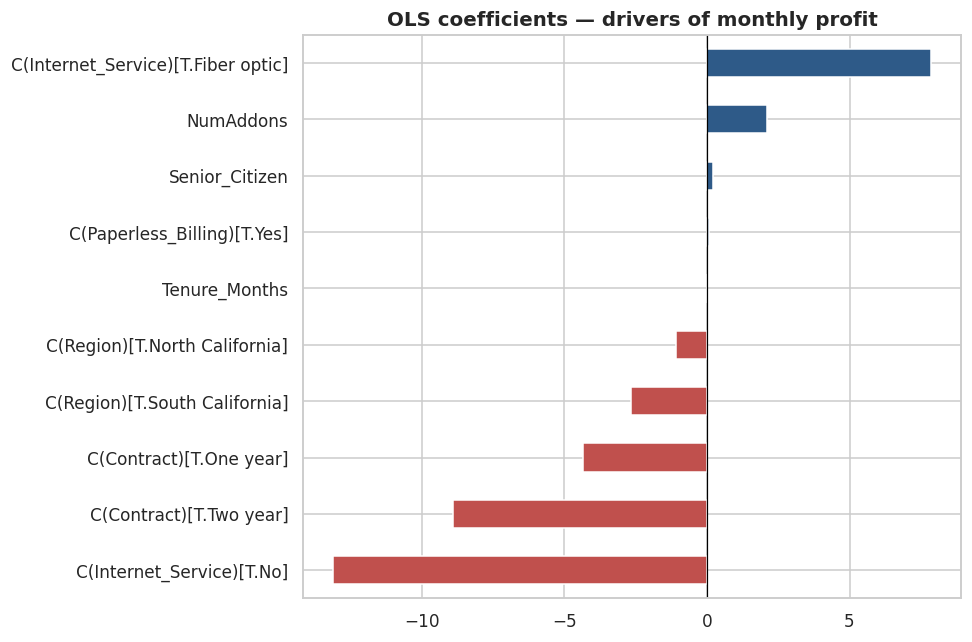

In [10]:
coef = (model.params.drop("Intercept")
        .sort_values()
        .rename("coefficient").to_frame())
fig, ax = plt.subplots(figsize=(9, 6))
colors = [DANGER if v < 0 else "#2E5A88" for v in coef["coefficient"]]
coef["coefficient"].plot.barh(ax=ax, color=colors)
ax.set_title("OLS coefficients — drivers of monthly profit")
ax.axvline(0, color="black", lw=.8)
plt.tight_layout(); save_fig(fig, "04_profit_drivers_ols"); plt.show()

## 6. Export segment table for the dashboard

In [11]:
scored = pd.read_csv(SCORED)[["CustomerID", "ChurnProbability"]]
export = (df.merge(scored, on="CustomerID", how="left")
          [["CustomerID", "Region", "Segment", "RFM_Segment", "Contract",
            "Tenure Months", "Monthly Charges", "MonthlyProfit", "CLV",
            "Churn Value", "ChurnProbability"]])
export.to_csv(SEG_OUT, index=False)
print(f"Saved {len(export):,} rows -> {SEG_OUT.relative_to(ROOT)}")
export.head()

Saved 7,043 rows -> data/processed/customer_segments.csv


,CustomerID,Region,Segment,RFM_Segment,Contract,Tenure Months,Monthly Charges,MonthlyProfit,CLV,Churn Value,ChurnProbability
0,8813-FVEQT,North California,Gold,Need Attention,Month-to-month,12,65.62,12.78,122.07,1,0.312315
1,3367-LWVXQ,South California,Gold,Loyal,One year,22,66.72,16.90,308.26,1,0.455416
2,8983-KPRZJ,Central California,Silver,Champions,Month-to-month,63,87.02,33.74,278.56,1,0.511286
3,8872-NCRZL,Central California,Silver,Loyal,Month-to-month,48,77.33,31.45,259.65,1,0.573745
4,5938-YXKTQ,Central California,Gold,Need Attention,Two year,7,50.51,11.85,362.61,0,0.158932


## Key takeaways
- The base splits cleanly into value tiers; the **top 1–2 tiers carry a
  disproportionate share of total profit**, while the **bottom 3 tiers** (flagged red)
  are retention/margin priorities.
- Cohort retention decays with months-since-signup but **recent contracted cohorts
  retain better** — consistent with the churn drivers in NB 03.
- Monte Carlo shows a tight, **profitable** band for next-year profit with negligible
  downside risk under the modeled assumptions.
- OLS confirms **longer tenure, more add-ons and longer contracts** associate with
  higher monthly profit; fiber-optic carries higher charges but also higher cost to
  serve.
